# Healthcare Insurance Cost Analysis

## Project Overview
This project explores a healthcare insurance dataset to understand what factors drive the cost of medical insurance charges. The workflow covers data cleaning, exploratory data analysis, SQL-based querying, and data visualisation to uncover insights that a healthcare insurer could act on.

**Tools used:** Python, pandas, sqlite3, seaborn, matplotlib

**Key Findings:**
- Smoking is the single biggest driver of insurance charges — smokers pay **~$32,050** on average compared to **~$8,441** for non-smokers, roughly 4x more.
- The combination of smoking and high BMI is especially costly: smokers with a BMI above 30 pay **~$41,693** on average, and smokers with a BMI above 40 form a "Very High Risk" group averaging **~$45,468**.
- Charges rise steadily with age, from **~$7,086** for the 0-18 group to **~$18,085** for the 50+ group.
- BMI has a strong relationship with cost for smokers (correlation ≈ 0.81) but a very weak one for non-smokers (correlation ≈ 0.08), meaning BMI mainly matters when combined with smoking.
- Region and sex have only a modest effect on charges compared to smoking status, BMI, and age.

## Setup

In [1]:
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("insurance.csv")

Loads the raw healthcare insurance dataset into a pandas DataFrame.

## Data Inspection

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


The first five rows confirm the dataset's structure: age, sex, BMI, number of children, smoking status, region, and insurance charges.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


All 1,338 rows have complete, non-null values across all seven columns, and each column's data type (numeric vs categorical) is as expected.

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Summary statistics show ages ranging from 18-64 and BMI from roughly 16-53, while charges range from about $1,122 to $63,770 — a wide spread suggesting a right-skewed distribution driven by a subset of high-cost individuals.

In [6]:
df.shape

(1338, 7)

The dataset contains 1,338 rows and 7 columns before cleaning.

In [7]:
unique_cols = ["sex", "children", "smoker", "region"]

for col in unique_cols:
    print(col)
    print(df[col].unique())
    print("-" * 30)

sex
<StringArray>
['female', 'male']
Length: 2, dtype: str
------------------------------
children
[0 1 3 2 5 4]
------------------------------
smoker
<StringArray>
['yes', 'no']
Length: 2, dtype: str
------------------------------
region
<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str
------------------------------


Each categorical column (sex, children, smoker, region) contains only expected, clean values with no typos or inconsistent categories.

## Data Cleaning

In [8]:
df.duplicated().sum()

np.int64(1)

One exact duplicate row is found in the dataset.

In [9]:
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


Both copies of the duplicate record (a 19-year-old male from the northwest) are displayed here before removal.

In [10]:
df = df.drop_duplicates()
print("Remaining duplicates:", df.duplicated().sum())
print("Shape after cleaning:", df.shape)

Remaining duplicates: 0
Shape after cleaning: (1337, 7)


After removing the duplicate, the dataset is reduced to 1,337 clean, unique rows ready for analysis.

## SQL Analysis

The cleaned dataset is loaded into an in-memory SQLite database so that business questions can be answered using SQL, a common requirement in analyst and BI roles.

In [11]:
conn = sqlite3.connect(':memory:')
df.to_sql('insurance', conn, index=False, if_exists='replace')

1337

Creates a temporary in-memory SQLite database and loads the cleaned data into an `insurance` table for querying.

### Descriptive Statistics

In [12]:
query_summary = """
SELECT AVG(charges) AS Average_Charge,
       MIN(charges) AS Minimum_Charge,
       MAX(charges) AS Maximum_Charge
FROM insurance
"""
pd.read_sql(query_summary, conn)

,Average_Charge,Minimum_Charge,Maximum_Charge
0,13279.121487,1121.8739,63770.42801


The average insurance charge is about $13,279, but the maximum charge (~$63,770) is nearly 5x the average, signalling that a small group of policyholders drive very high costs.

In [13]:
query_smoker_count = "SELECT smoker, COUNT(*) AS Number_of_People FROM insurance GROUP BY smoker"
pd.read_sql(query_smoker_count, conn)

,smoker,Number_of_People
0,no,1063
1,yes,274


Only 274 of 1,337 people (about 20%) are smokers, yet as later queries show, they account for a disproportionate share of high charges.

In [14]:
query_avg_bmi = "SELECT AVG(bmi) AS Average_BMI FROM insurance"
pd.read_sql(query_avg_bmi, conn)

,Average_BMI
0,30.663452


The average BMI across all policyholders is about 30.7, which falls in the clinically 'obese' range, indicating the overall population carries elevated health risk.

### Segment Comparisons

In [15]:
query_sex = "SELECT sex, AVG(charges) AS Average_Charge FROM insurance GROUP BY sex"
pd.read_sql(query_sex, conn)

,sex,Average_Charge
0,female,12569.578844
1,male,13974.998864


Male policyholders pay slightly more on average (~$13,975) than female policyholders (~$12,570), but the gap is modest compared to other factors like smoking.

In [16]:
query_region = """
SELECT region, COUNT(*) AS Number_of_People, AVG(charges) AS Average_Charge
FROM insurance
GROUP BY region
ORDER BY Average_Charge DESC
"""
pd.read_sql(query_region, conn)

,region,Number_of_People,Average_Charge
0,southeast,364,14735.411438
1,northeast,324,13406.384516
2,northwest,324,12450.840844
3,southwest,325,12346.937377


The southeast region has both the most policyholders and the highest average charge (~$14,735), while the southwest has the lowest average charge (~$12,347).

In [17]:
query_bmi_region = "SELECT region, AVG(bmi) AS Average_BMI FROM insurance GROUP BY region"
pd.read_sql(query_bmi_region, conn)

,region,Average_BMI
0,northeast,29.173503
1,northwest,29.195494
2,southeast,33.355989
3,southwest,30.596615


The southeast also has the highest average BMI (~33.4) of any region, which likely helps explain why it also has the highest average charges.

### Filtering & Subqueries

In [18]:
query_children = "SELECT COUNT(*) AS People_With_3_Plus_Children FROM insurance WHERE children > 2"
pd.read_sql(query_children, conn)

,People_With_3_Plus_Children
0,200


200 policyholders have more than two children, a segment worth tracking separately for family-plan pricing.

In [19]:
query_high_bmi = "SELECT AVG(charges) AS Avg_Charge_High_BMI FROM insurance WHERE bmi > 30"
pd.read_sql(query_high_bmi, conn)

,Avg_Charge_High_BMI
0,15580.700985


People with a BMI above 30 pay about $15,581 on average, noticeably higher than the overall average of $13,279.

In [20]:
query_smoker_high_bmi = "SELECT AVG(charges) AS Avg_Charge_Smoker_High_BMI FROM insurance WHERE bmi > 30 AND smoker = \'yes\'"
pd.read_sql(query_smoker_high_bmi, conn)

,Avg_Charge_Smoker_High_BMI
0,41692.808992


Smokers who also have a BMI above 30 pay about $41,693 on average, roughly 5x the average non-smoker's charge, showing these two risk factors compound each other.

In [21]:
query_above_avg = "SELECT * FROM insurance WHERE charges > (SELECT AVG(charges) FROM insurance)"
pd.read_sql(query_above_avg, conn)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,33,male,22.705,0,no,northwest,21984.47061
2,60,female,25.840,0,no,northwest,28923.13692
3,62,female,26.290,0,yes,southeast,27808.72510
4,27,male,42.130,0,yes,southeast,39611.75770
...,...,...,...,...,...,...,...
415,35,male,39.710,4,no,northeast,19496.71917
416,62,male,26.695,0,yes,northeast,28101.33305
417,42,female,40.370,2,yes,southeast,43896.37630
418,23,female,24.225,2,no,northeast,22395.74424


This query isolates every policyholder paying more than the overall average charge, a group that can be used to investigate common risk traits.

In [22]:
query_above_regional_avg = """
SELECT * FROM insurance i
WHERE charges > (SELECT AVG(charges) FROM insurance WHERE region = i.region)
"""
pd.read_sql(query_above_regional_avg, conn)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,33,male,22.705,0,no,northwest,21984.47061
2,60,female,25.840,0,no,northwest,28923.13692
3,62,female,26.290,0,yes,southeast,27808.72510
4,27,male,42.130,0,yes,southeast,39611.75770
...,...,...,...,...,...,...,...
423,35,male,39.710,4,no,northeast,19496.71917
424,62,male,26.695,0,yes,northeast,28101.33305
425,42,female,40.370,2,yes,southeast,43896.37630
426,23,female,24.225,2,no,northeast,22395.74424


Using a correlated subquery, this identifies policyholders who pay more than their own region's average, a more locally relevant definition of 'high cost' than a single global threshold.

### Risk & Cost Categorization

In [23]:
query_bmi_category = """
SELECT *,
CASE
    WHEN bmi < 18.5 THEN \'Underweight\'
    WHEN bmi < 25 THEN \'Healthy\'
    WHEN bmi < 30 THEN \'Overweight\'
    ELSE \'Obese\'
END AS bmi_category
FROM insurance
"""
pd.read_sql(query_bmi_category, conn)

,age,sex,bmi,children,smoker,region,charges,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Healthy
4,32,male,28.880,0,no,northwest,3866.85520,Overweight
...,...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830,Obese
1333,18,female,31.920,0,no,northeast,2205.98080,Obese
1334,18,female,36.850,0,no,southeast,1629.83350,Obese
1335,21,female,25.800,0,no,southwest,2007.94500,Overweight


Adds a clinical BMI category to every row, the foundation for the group-level cost comparison in the next query.

In [24]:
query_bmi_category_summary = """
SELECT
    CASE
        WHEN bmi < 18.5 THEN \'Underweight\'
        WHEN bmi < 25 THEN \'Healthy\'
        WHEN bmi < 30 THEN \'Overweight\'
        ELSE \'Obese\'
    END AS bmi_category,
    COUNT(*) AS Number_of_People,
    AVG(charges) AS Average_Charge
FROM insurance
GROUP BY bmi_category
"""
pd.read_sql(query_bmi_category_summary, conn)

,bmi_category,Number_of_People,Average_Charge
0,Healthy,225,10409.337709
1,Obese,706,15572.041945
2,Overweight,386,10987.509891
3,Underweight,20,8852.200585


The 'Obese' group (706 people, the majority of the dataset) has the highest average charge at ~$15,572, confirming BMI category is a meaningful cost driver on its own.

In [25]:
query_smoker_summary = """
SELECT smoker,
       COUNT(*) AS Number_of_People,
       AVG(charges) AS Average_Charge,
       MIN(charges) AS Min_Charge,
       MAX(charges) AS Max_Charge
FROM insurance
GROUP BY smoker
"""
pd.read_sql(query_smoker_summary, conn)

,smoker,Number_of_People,Average_Charge,Min_Charge,Max_Charge
0,no,1063,8440.660307,1121.8739,36910.60803
1,yes,274,32050.231832,12829.4551,63770.42801


Smokers average $32,050 in charges (as high as $63,770) compared to $8,441 for non-smokers (topping out at $36,911) — even the cheapest smoker ($12,829) pays more than the average non-smoker.

In [26]:
query_risk_category = """
SELECT
    CASE
        WHEN bmi < 30 AND smoker = \'no\' THEN \'Low Risk\'
        WHEN bmi > 40 AND smoker = \'yes\' THEN \'Very High Risk\'
        WHEN bmi > 30 AND age > 40 THEN \'High Risk\'
        ELSE \'Medium Risk\'
    END AS risk_category,
    COUNT(*) AS Number_of_People,
    AVG(charges) AS Average_Charge
FROM insurance
GROUP BY risk_category
ORDER BY Average_Charge DESC
"""
pd.read_sql(query_risk_category, conn)

,risk_category,Number_of_People,Average_Charge
0,Very High Risk,21,45467.786146
1,High Risk,355,17134.381367
2,Medium Risk,459,14623.502645
3,Low Risk,502,7977.029520


Combining BMI, age, and smoking status into a single risk score shows a clear gradient: 'Very High Risk' policyholders (smokers with BMI over 40) pay ~$45,468 on average, over 5x more than the 'Low Risk' group (~$7,977), demonstrating the value of multi-factor risk scoring over any single variable.

### Window Functions & Rankings

In [27]:
query_regional_avg_window = """
SELECT *, AVG(charges) OVER(PARTITION BY region) AS regional_avg_charge
FROM insurance
"""
pd.read_sql(query_regional_avg_window, conn)

,age,sex,bmi,children,smoker,region,charges,regional_avg_charge
0,37,male,29.830,2,no,northeast,6406.41070,13406.384516
1,25,male,26.220,0,no,northeast,2721.32080,13406.384516
2,52,female,30.780,1,no,northeast,10797.33620,13406.384516
3,23,male,23.845,0,no,northeast,2395.17155,13406.384516
4,60,female,36.005,0,no,northeast,13228.84695,13406.384516
...,...,...,...,...,...,...,...,...
1332,19,female,20.600,0,no,southwest,1731.67700,12346.937377
1333,52,male,38.600,2,no,southwest,10325.20600,12346.937377
1334,23,female,33.400,0,no,southwest,10795.93733,12346.937377
1335,52,female,44.700,3,no,southwest,11411.68500,12346.937377


A window function attaches each policyholder's regional average charge to their own row without collapsing the dataset, making it easy to compare an individual to their regional benchmark.

In [28]:
query_rank_by_charge = """
SELECT *, RANK() OVER(ORDER BY charges DESC) AS charge_rank
FROM insurance
"""
pd.read_sql(query_rank_by_charge, conn)

,age,sex,bmi,children,smoker,region,charges,charge_rank
0,54,female,47.410,0,yes,southeast,63770.42801,1
1,45,male,30.360,0,yes,southeast,62592.87309,2
2,52,male,34.485,3,yes,northwest,60021.39897,3
3,31,female,38.095,1,yes,northeast,58571.07448,4
4,33,female,35.530,0,yes,northwest,55135.40209,5
...,...,...,...,...,...,...,...,...
1332,18,male,34.100,0,no,southeast,1137.01100,1333
1333,18,male,33.660,0,no,southeast,1136.39940,1334
1334,18,male,33.330,0,no,southeast,1135.94070,1335
1335,18,male,30.140,0,no,southeast,1131.50660,1336


Ranks every policyholder from highest to lowest charge, useful for quickly identifying the most expensive cases across the entire book of business.

In [29]:
query_top3_per_region = """
SELECT * FROM (
    SELECT *, RANK() OVER(PARTITION BY region ORDER BY charges DESC) AS regional_rank
    FROM insurance
) WHERE regional_rank <= 3
"""
pd.read_sql(query_top3_per_region, conn)

,age,sex,bmi,children,smoker,region,charges,regional_rank
0,31,female,38.095,1,yes,northeast,58571.07448,1
1,54,male,40.565,3,yes,northeast,48549.17835,2
2,61,female,36.385,1,yes,northeast,48517.56315,3
3,52,male,34.485,3,yes,northwest,60021.39897,1
4,33,female,35.530,0,yes,northwest,55135.40209,2
5,58,male,36.955,2,yes,northwest,47496.49445,3
6,54,female,47.410,0,yes,southeast,63770.42801,1
7,45,male,30.360,0,yes,southeast,62592.87309,2
8,64,male,36.960,2,yes,southeast,49577.66240,3
9,60,male,32.800,0,yes,southwest,52590.82939,1


Identifies the three highest-charged policyholders in each region, useful for spotting the specific claims driving up regional averages, several of which exceed $55,000.

In [30]:
query_diff_from_regional_max = """
SELECT *,
       MAX(charges) OVER(PARTITION BY region) - charges AS diff_from_regional_max
FROM insurance
"""
pd.read_sql(query_diff_from_regional_max, conn)

,age,sex,bmi,children,smoker,region,charges,diff_from_regional_max
0,37,male,29.830,2,no,northeast,6406.41070,52164.66378
1,25,male,26.220,0,no,northeast,2721.32080,55849.75368
2,52,female,30.780,1,no,northeast,10797.33620,47773.73828
3,23,male,23.845,0,no,northeast,2395.17155,56175.90293
4,60,female,36.005,0,no,northeast,13228.84695,45342.22753
...,...,...,...,...,...,...,...,...
1332,19,female,20.600,0,no,southwest,1731.67700,50859.15239
1333,52,male,38.600,2,no,southwest,10325.20600,42265.62339
1334,23,female,33.400,0,no,southwest,10795.93733,41794.89206
1335,52,female,44.700,3,no,southwest,11411.68500,41179.14439


Calculates how far each policyholder's charge sits below the highest charge in their region, giving a quick sense of how much of an outlier the top payer is compared to their peers.

In [31]:
query_above_bmi_category_avg = """
SELECT * FROM (
    SELECT *, AVG(charges) OVER(PARTITION BY bmi_category) AS bmi_category_avg_charge
    FROM (
        SELECT *,
            CASE
                WHEN bmi < 18.5 THEN \'Underweight\'
                WHEN bmi < 25 THEN \'Healthy\'
                WHEN bmi < 30 THEN \'Overweight\'
                ELSE \'Obese\'
            END AS bmi_category
        FROM insurance
    )
)
WHERE charges > bmi_category_avg_charge
"""
pd.read_sql(query_above_bmi_category_avg, conn)

,age,sex,bmi,children,smoker,region,charges,bmi_category,bmi_category_avg_charge
0,33,male,22.705,0,no,northwest,21984.47061,Healthy,10409.337709
1,63,female,23.085,0,no,northeast,14451.83515,Healthy,10409.337709
2,60,female,24.530,0,no,southeast,12629.89670,Healthy,10409.337709
3,53,female,22.880,1,yes,southeast,23244.79020,Healthy,10409.337709
4,64,male,24.700,1,no,northwest,30166.61817,Healthy,10409.337709
...,...,...,...,...,...,...,...,...,...
450,26,female,17.195,2,yes,northeast,14455.64405,Underweight,8852.200585
451,57,male,18.335,0,no,northeast,11534.87265,Underweight,8852.200585
452,60,female,18.335,0,no,northeast,13204.28565,Underweight,8852.200585
453,39,female,18.300,5,yes,southwest,19023.26000,Underweight,8852.200585


Combines a CASE categorization with a window function to flag policyholders paying more than the average for their own BMI category, a more precise definition of 'above average' than comparing everyone to a single global number.

## Data Visualisation

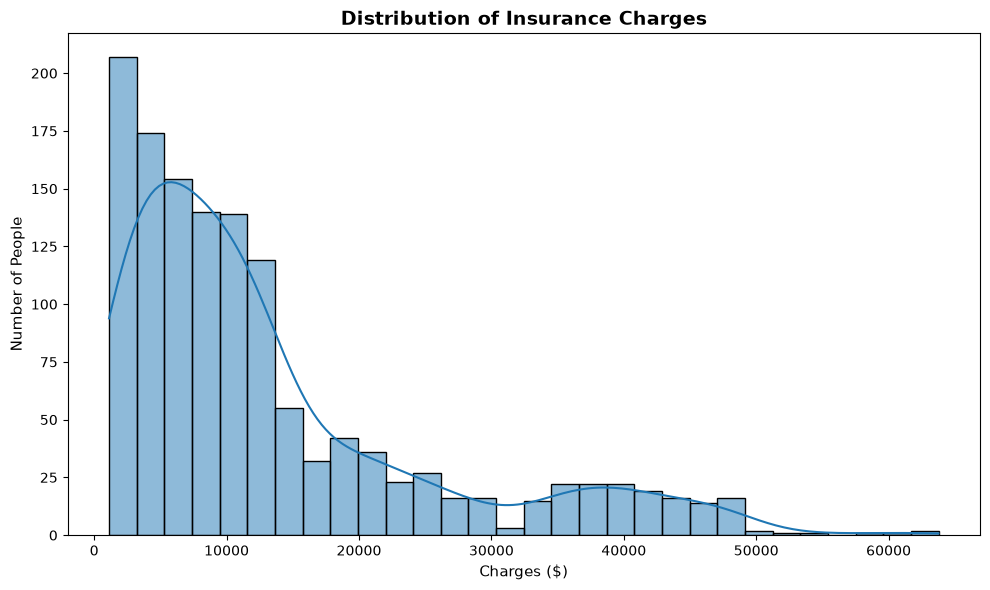

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(df, x="charges", bins=30, kde=True)
plt.title("Distribution of Insurance Charges", fontsize=14, fontweight="bold")
plt.xlabel("Charges ($)", fontsize=11)
plt.ylabel("Number of People", fontsize=11)
plt.tight_layout()
plt.show()

This histogram shows that most charges are concentrated below $15,000, with a long right tail stretching out to about $63,000 — a skew that matches the small group of high-BMI smokers who pay dramatically more than everyone else.

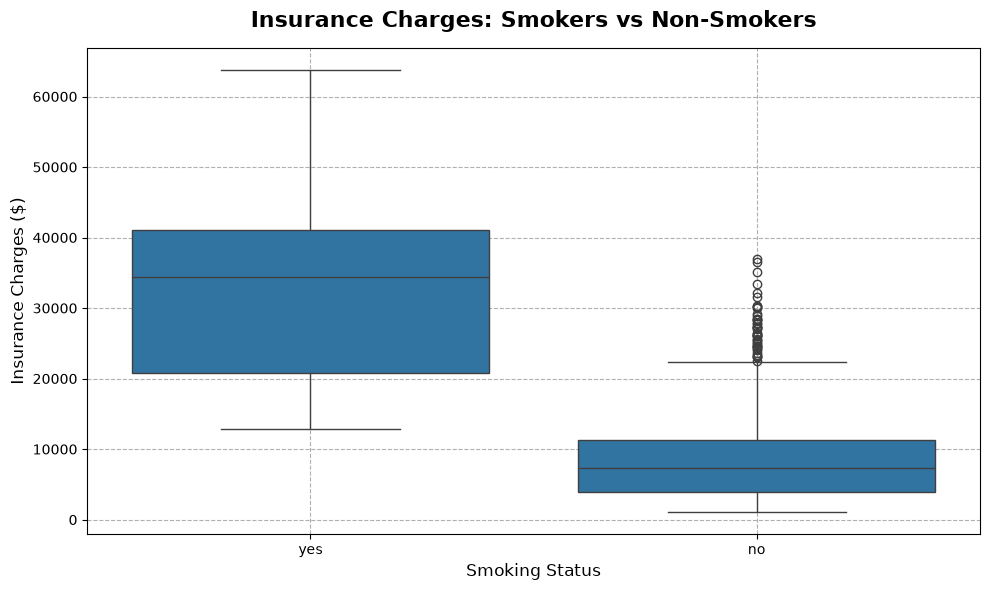

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x="smoker", y="charges", ax=ax)
ax.set_title("Insurance Charges: Smokers vs Non-Smokers", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Smoking Status", fontsize=12)
ax.set_ylabel("Insurance Charges ($)", fontsize=12)
ax.grid(True, linestyle="--")
plt.tight_layout()
plt.show()

This box plot shows a stark separation between the two groups: even the highest-charged non-smokers fall around the median of the smoking group, confirming that smoking status alone explains a large share of the variation in insurance cost.

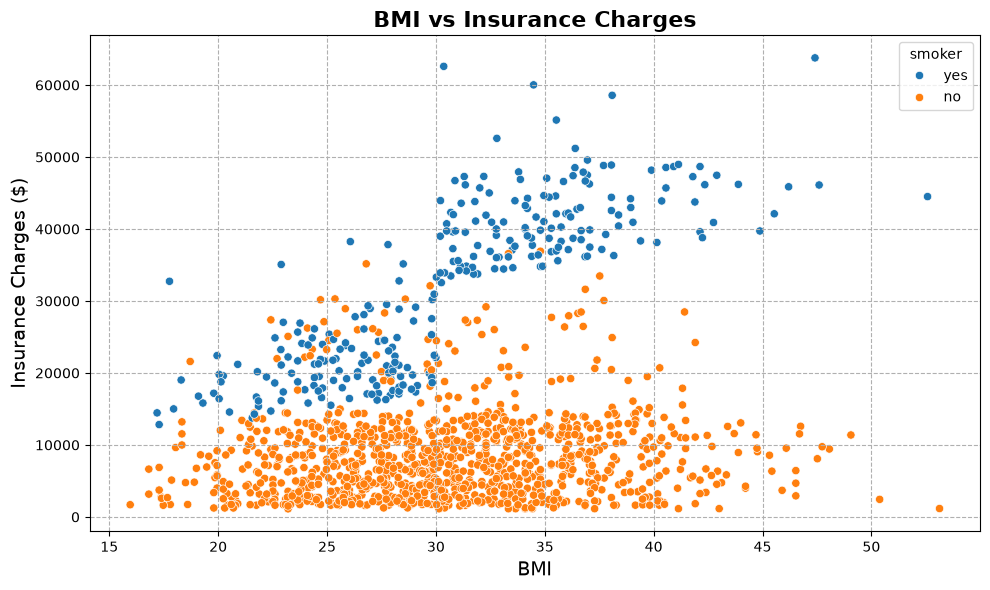

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", ax=ax)
ax.set_title("BMI vs Insurance Charges", fontsize=16, fontweight="bold")
ax.set_xlabel("BMI", fontsize=14)
ax.set_ylabel("Insurance Charges ($)", fontsize=14)
ax.grid(True, linestyle="--")
plt.tight_layout()
plt.show()

This scatter plot shows that BMI has little relationship with charges for non-smokers (correlation ≈ 0.08), but a strong positive relationship for smokers (correlation ≈ 0.81), visually confirming that BMI mainly drives up cost when combined with smoking.

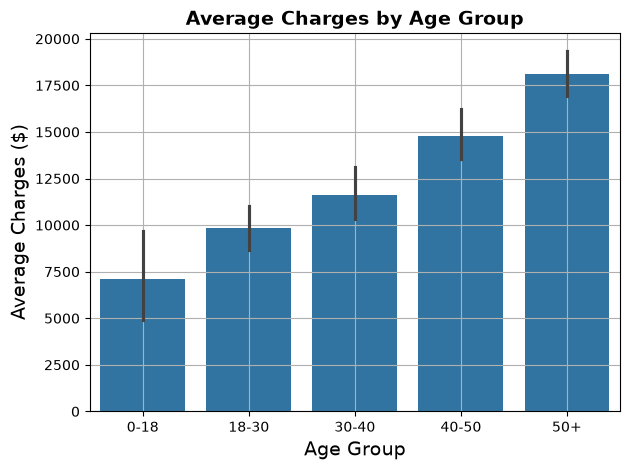

In [35]:
df["age_group"] = pd.cut(df["age"],
                          bins=[0, 18, 30, 40, 50, 100],
                          labels=['0-18', '18-30', '30-40', '40-50', '50+'])
sns.barplot(data=df, x="age_group", y="charges")
plt.title("Average Charges by Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Age Group", fontsize=14)
plt.ylabel("Average Charges ($)", fontsize=14)
plt.tight_layout()
plt.grid(True)
plt.show()

Average charges rise steadily with age, from about $7,086 in the 0-18 group to about $18,085 in the 50+ group, reflecting the expected increase in health risk and claims as policyholders get older.

## Conclusion & Business Recommendations

### Key Findings
- **Smoking is the dominant cost driver.** Smokers pay roughly 4x more than non-smokers on average ($32,050 vs $8,441), and this gap holds regardless of other factors.
- **BMI compounds risk, but mainly for smokers.** BMI correlates strongly with charges for smokers (r ≈ 0.81) but barely at all for non-smokers (r ≈ 0.08). The combination of obesity and smoking is the single most expensive profile in the dataset (~$41,693 average, rising to ~$45,468 for the highest-BMI smokers).
- **Age has a steady, moderate effect.** Charges increase from ~$7,086 (0-18) to ~$18,085 (50+), consistent with rising health risk over time.
- **Region and sex matter less.** The southeast region has the highest average charges (~$14,735), partly explained by having the highest average BMI (~33.4) of any region, but the effect is small next to smoking and BMI.
- **A small number of high-BMI smokers drive a disproportionate share of total cost**, visible in both the right-skewed charge distribution and the "Very High Risk" segment identified through categorization.

### Business Recommendations
1. **Prioritize smoking-cessation incentives.** Since smoking is the largest single driver of cost, offering premium discounts or wellness-program incentives for quitting could meaningfully reduce claims costs over time.
2. **Use combined risk scoring, not single factors, for underwriting.** BMI alone is a weak predictor for non-smokers; pricing models should weight the *interaction* between BMI and smoking status rather than treating them independently.
3. **Target wellness programs at high-BMI smokers.** This group represents the highest-cost segment by a wide margin; even modest improvements in BMI or smoking cessation within this segment would have an outsized impact on total claims.
4. **Review regional pricing in the southeast.** Higher average BMI in this region correlates with higher charges — regional premium adjustments or region-specific wellness outreach may be warranted.
5. **Monitor the highest-cost outliers separately.** A small number of very high-charge policyholders (largely high-BMI smokers) pull the entire cost distribution upward; case management or targeted intervention for this group could reduce tail-risk exposure.